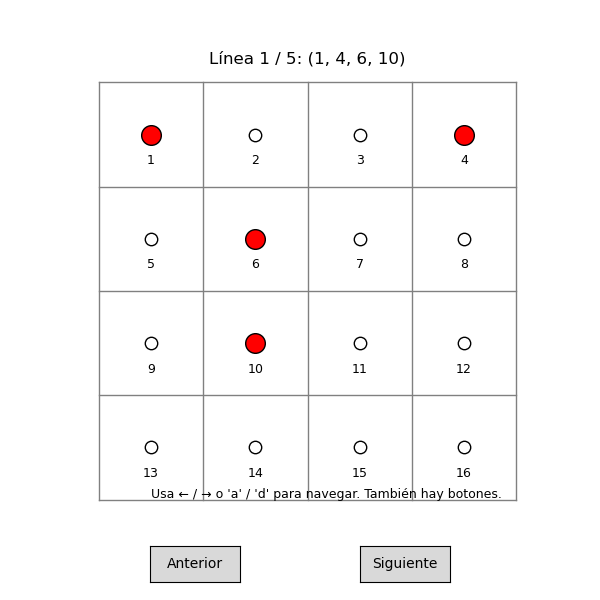

Líneas de prueba (L):
1: (1, 4, 6, 10)
2: (2, 3, 7, 11)
3: (5, 6, 7, 8)
4: (9, 13, 14, 16)
5: (1, 5, 9, 13)


In [1]:
%matplotlib widget

# Código para visualizar un plano afín 4x4 con líneas seleccionables con las teclas de flecha.
# Ejecuta esta celda en un notebook (se intentó usar interacción por teclas y botones).
# Mapa de puntos: 1..16 van en orden fila-major, de izquierda a derecha, de arriba a abajo.
# Ej.: fila 0 (arriba): 1 2 3 4; fila 1: 5 6 7 8; ... fila 3 (abajo): 13 14 15 16.
# Flechas derecha/izquierda o teclas 'd'/'a' para avanzar/retroceder. También hay botones en pantalla.

import matplotlib.pyplot as plt
from matplotlib.widgets import Button
import numpy as np

# Mapeo de índices a coordenadas (x,y)
def index_to_coord(idx):
    # idx in 1..16
    i = idx - 1
    row = i // 4   # 0..3 top->bottom
    col = i % 4    # 0..3 left->right
    # Para que la fila 0 quede en y=3 (arriba) y filaa 3 en y=0 (abajo) invertimos:
    x = col
    y = 3 - row
    return (x, y)

coords = {i: index_to_coord(i) for i in range(1,17)}

# Ejemplos de 5 "líneas" (cada una con 4 puntos). 
# (Estas son listas de ejemplo para probar la interfaz; no pretenden ser líneas del proyectivo)
L = [
    (1, 4, 6, 10),
    (2, 3, 7, 11),
    (5, 6, 7, 8),
    (9, 13, 14, 16),
    (1, 5, 9, 13)
]

# Variables de estado
current = {"idx": 0}  # diccionario para mutabilidad desde los handlers

# Función que dibuja el tablero y resalta la línea actual
def draw_board(ax, line_idx):
    ax.clear()
    # Dibujar la cuadrícula 4x4
    for x in range(5):
        ax.plot([x-0.5, x-0.5], [-0.5, 3.5], color='gray', linewidth=1, zorder=0)
    for y in range(5):
        ax.plot([-0.5, 3.5], [y-0.5, y-0.5], color='gray', linewidth=1, zorder=0)
    
    # Dibujar puntos y etiquetas
    xs = [coords[i][0] for i in range(1,17)]
    ys = [coords[i][1] for i in range(1,17)]
    
    # Determinar puntos seleccionados
    sel = set(L[line_idx])
    
    # Dibujar todos los puntos (puntos "no seleccionados")
    for i in range(1,17):
        x,y = coords[i]
        if i in sel:
            ax.scatter(x, y, s=200, marker='o', facecolors='red', edgecolors='black', zorder=3)
        else:
            ax.scatter(x, y, s=80, marker='o', facecolors='white', edgecolors='black', zorder=2)
        ax.text(x, y-0.25, str(i), ha='center', va='center', fontsize=9, zorder=4)
    
    # Añadir un título que indique la línea actual
    ax.set_title(f"Línea {line_idx+1} / {len(L)}: {tuple(L[line_idx])}", fontsize=12)
    ax.set_xlim(-0.6, 3.6)
    ax.set_ylim(-0.6, 3.6)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Opcional: dibujar una pequeña leyenda en el margen inferior
    ax.text(0, -0.45, "Usa ← / → o 'a' / 'd' para navegar. También hay botones.", fontsize=9, va='center')

# Setup figura y ejes
fig, ax = plt.subplots(figsize=(6,6))
plt.subplots_adjust(bottom=0.15)  # espacio para botones

# Dibujar por primera vez
draw_board(ax, current["idx"])

# Handlers para teclas
def on_key(event):
    if event.key in ['right', 'd', 'arrowright']:
        current["idx"] = (current["idx"] + 1) % len(L)
        draw_board(ax, current["idx"])
        fig.canvas.draw_idle()
    elif event.key in ['left', 'a', 'arrowleft']:
        current["idx"] = (current["idx"] - 1) % len(L)
        draw_board(ax, current["idx"])
        fig.canvas.draw_idle()

fig.canvas.mpl_connect('key_press_event', on_key)

# Botones (izquierda/derecha) por si no funcionan las teclas
axprev = plt.axes([0.25, 0.03, 0.15, 0.06])
axnext = plt.axes([0.60, 0.03, 0.15, 0.06])
bprev = Button(axprev, 'Anterior')
bnext = Button(axnext, 'Siguiente')

def prev(event):
    current["idx"] = (current["idx"] - 1) % len(L)
    draw_board(ax, current["idx"])
    fig.canvas.draw_idle()

def nex(event):
    current["idx"] = (current["idx"] + 1) % len(L)
    draw_board(ax, current["idx"])
    fig.canvas.draw_idle()

bprev.on_clicked(prev)
bnext.on_clicked(nex)

plt.show()

# Mostrar las líneas de ejemplo para referencia
print("Líneas de prueba (L):")
for i, line in enumerate(L, start=1):
    print(f"{i}: {line}")

# Notas breves:
# - Si ejecutas esto en un notebook con backend interactivo (por ejemplo, %matplotlib notebook o ipympl)
#   las teclas y botones deberían funcionar de forma interactiva. Si usas %matplotlib inline, los botones
#   pueden no responder; en ese caso, cambia el backend a uno interactivo.
# - Si quieres que dibuje segmentos conectando los puntos de la línea, puedo agregar esa funcionalidad.

In [32]:
# Construcción de las líneas de PG(2,8) sin dependencias externas.

from itertools import product
from IPython.display import display, clear_output
import time

In [33]:

# Polinomio irreducible para GF(8): x^3 + x + 1  -> bits 0b1011
IRRED_POLY = 0b1011

def gf_add(a, b):
    return a ^ b

def gf_mul(a, b):
    # multiplicación de polinomios representados en bits, reducción por IRRED_POLY
    res = 0
    for i in range(3):           # grados 0..2 de 'a'
        if (a >> i) & 1:
            res ^= (b << i)
    # reducir términos de grado >= 3
    while res >> 3:
        shift = (res.bit_length() - 1) - 3
        res ^= (IRRED_POLY << shift)
    return res & 0b111

def gf_pow(a, e):
    if a == 0:
        return 0 if e > 0 else 1
    res = 1
    base = a
    ee = e
    while ee:
        if ee & 1:
            res = gf_mul(res, base)
        base = gf_mul(base, base)
        ee >>= 1
    return res

def gf_inv(a):
    if a == 0:
        raise ZeroDivisionError("0 no tiene inverso")
    # en GF(q), a^{-1} = a^{q-2}; aquí q = 8 => exponent = 6
    return gf_pow(a, 6)

def normalize_point(pt):
    # Canonicaliza (x,y,z): divide por la primera coordenada no nula para que sea 1.
    x,y,z = pt
    if x != 0:
        inv = gf_inv(x); return (1, gf_mul(y, inv), gf_mul(z, inv))
    elif y != 0:
        inv = gf_inv(y); return (0, 1, gf_mul(z, inv))
    else:
        inv = gf_inv(z); return (0, 0, 1)

# 1) generar todos los puntos proyectivos (representante canónico)
all_pts = set()
for x,y,z in product(range(8), repeat=3):
    if x == 0 and y == 0 and z == 0:
        continue
    all_pts.add(normalize_point((x,y,z)))
points_list = sorted(all_pts)   # lista de representantes canónicos
# should be 8^2 + 8 + 1 = 73
print("Número de puntos proyectivos (representantes canónicos):", len(points_list))

# 2) generar todos los coeficientes (a,b,c) no nulos y normalizarlos para identificar líneas únicas
all_coeffs = set()
for a,b,c in product(range(8), repeat=3):
    if a == 0 and b == 0 and c == 0:
        continue
    if a != 0:
        inv = gf_inv(a); all_coeffs.add((1, gf_mul(b, inv), gf_mul(c, inv)))
    elif b != 0:
        inv = gf_inv(b); all_coeffs.add((0, 1, gf_mul(c, inv)))
    else:
        inv = gf_inv(c); all_coeffs.add((0, 0, 1))
coeffs_list = sorted(all_coeffs)

def lin_comb(a,b,c,x,y,z):
    return gf_add(gf_add(gf_mul(a,x), gf_mul(b,y)), gf_mul(c,z))

# 3) para cada coef triple (normalizado) obtener la línea { [x:y:z] : a x + b y + c z = 0 }
L = []
seen = set()
for (a,b,c) in coeffs_list:
    pts = [pt for pt in points_list if lin_comb(a,b,c, *pt) == 0]
    pts_t = tuple(sorted(pts))
    if pts_t not in seen:
        seen.add(pts_t)
        L.append(pts_t)
L = sorted(L)

# 4) comprobaciones rápidas
print("Número de líneas halladas:", len(L))
sizes = sorted({len(line) for line in L})
print("Tamaños distintos de líneas (debe ser [9]):", sizes)

# 5) ejemplos (no imprimir todo si lo ejecutas)
print("\nEjemplos: primeros 6 puntos (canónicos):")
for p in points_list[:6]:
    print(" ", p)
print("\nPrimeras 6 líneas (cada línea lista sus puntos):")
for i,line in enumerate(L[:6], start=1):
    print(f"L{i:02d} (size={len(line)}): {line}")

# `L` es la lista final que pediste: lista de tuplas; cada tupla contiene 9 puntos normalizados.
# Puedes usar la variable `L` después de ejecutar para inspeccionar o exportar.

Número de puntos proyectivos (representantes canónicos): 73
Número de líneas halladas: 73
Tamaños distintos de líneas (debe ser [9]): [9]

Ejemplos: primeros 6 puntos (canónicos):
  (0, 0, 1)
  (0, 1, 0)
  (0, 1, 1)
  (0, 1, 2)
  (0, 1, 3)
  (0, 1, 4)

Primeras 6 líneas (cada línea lista sus puntos):
L01 (size=9): ((0, 0, 1), (0, 1, 0), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 1, 4), (0, 1, 5), (0, 1, 6), (0, 1, 7))
L02 (size=9): ((0, 0, 1), (1, 0, 0), (1, 0, 1), (1, 0, 2), (1, 0, 3), (1, 0, 4), (1, 0, 5), (1, 0, 6), (1, 0, 7))
L03 (size=9): ((0, 0, 1), (1, 1, 0), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 1, 4), (1, 1, 5), (1, 1, 6), (1, 1, 7))
L04 (size=9): ((0, 0, 1), (1, 2, 0), (1, 2, 1), (1, 2, 2), (1, 2, 3), (1, 2, 4), (1, 2, 5), (1, 2, 6), (1, 2, 7))
L05 (size=9): ((0, 0, 1), (1, 3, 0), (1, 3, 1), (1, 3, 2), (1, 3, 3), (1, 3, 4), (1, 3, 5), (1, 3, 6), (1, 3, 7))
L06 (size=9): ((0, 0, 1), (1, 4, 0), (1, 4, 1), (1, 4, 2), (1, 4, 3), (1, 4, 4), (1, 4, 5), (1, 4, 6), (1, 4, 7))


In [34]:
def det3(a, b, c):
    x1,y1,z1 = a
    x2,y2,z2 = b
    x3,y3,z3 = c
    return gf_add(
        gf_add(
            gf_add( gf_mul(x1, gf_mul(y2, z3)), gf_mul(y1, gf_mul(z2, x3)) ), gf_mul(z1, gf_mul(x2, y3))
        ),
        gf_add(
            gf_add( gf_mul(x3, gf_mul(y2, z1)), gf_mul(y3, gf_mul(z2, x1)) ), gf_mul(z3, gf_mul(x2, y1))
        )
    )

def collinear(a,b,c):
    return det3(a,b,c) == 0

In [35]:
affine_points = [pt for pt in points_list if pt[2] != 0]
print("Número de puntos afines (z != 0):", len(affine_points))

Número de puntos afines (z != 0): 64


In [102]:
def solve_coloring(affine_points, num_colors=7, H=0):
    """
    Try to color affine_points with colors {0,...,num_colors-1}
    so that no color class contains 3 collinear points.

    Assumes:
        - affine_points is a list of projective points
        - collinear(a,b,c) is defined globally
    """
    N = len(affine_points)

    # assignment: color[i] = assigned color or None
    assign = [None] * N

    # domain: colors available for each point
    domains = [set(range(num_colors)) for _ in range(N)]

    # for each color, track which points have that color so far
    color_class = {c: [] for c in range(num_colors)}

    # bookkeeping to undo changes
    change_stack = []

    for j, point in enumerate(H):
        if point in H:
            assign[j]=0
            color_class[0].append(j)
        else:
            domains[j].remove(0)

    nodes_explored = 0
    max_depth_reached = 0

    last_update_time = 0   # throttle updates so we don't refresh too often

    # ----------- helpers -----------

    def push_change(entry):
        change_stack.append(entry)

    def undo_changes(count):
        """Undo last `count` changes"""
        for _ in range(count):
            typ, data = change_stack.pop()
            if typ == "assign":
                p, old_color = data
                assign[p] = old_color
            elif typ == "domain_remove":
                p, c = data
                domains[p].add(c)
            elif typ == "color_class_remove":
                p, c = data
                color_class[c].remove(p)

    def update_progress(depth):
        """Update a progress bar in Jupyter without spamming output."""
        nonlocal nodes_explored, max_depth_reached, last_update_time

        nodes_explored += 1

        # Whenever a new max depth is reached, store current assignment it in a new line of partial.txt
        if depth > max_depth_reached:
            with open(f"partial_{num_colors}.txt", "a") as f:
                f.write(",".join(str(assign[i]) if assign[i] is not None else "-" for i in range(N)) + "\n")

        max_depth_reached = max(max_depth_reached, depth)



        # Only update every ~0.1s (tunable)
        now = time.time()
        if now - last_update_time > 0.1:
            last_update_time = now
            clear_output(wait=True)
            print(f"Explored nodes: {nodes_explored:,}   (current depth: {depth})  Max depth: {max_depth_reached}")

    # ----------- MRV: choose unassigned variable with smallest domain -----------
    def select_unassigned_variable():
        best = None
        best_size = 10**9
        for p in range(N):
            if assign[p] is None:
                dsize = len(domains[p])
                if dsize < best_size:
                    best_size = dsize
                    best = p
        return best

    # ----------- Forward checking after assigning p→c -----------
    def forward_check(p, c):
        """Return True if consistent, otherwise False. Changes recorded for undo."""
        # (1) Record assignment
        old_color = assign[p]
        assign[p] = c
        push_change(("assign", (p, old_color)))

        # (2) Add to color class
        color_class[c].append(p)
        push_change(("color_class_remove", (p, c)))  # undo= remove from list

        # (3) If do not allow two classes to have size 10
        # sizes = [len(color_class[cc]) for cc in range(num_colors)]
        # if sizes.count(10) > 1:
        #     return False

        # (4) For the same color class c, check pairs
        for q in color_class[c]:
            if q == p: 
                continue
            # For every third point r not yet assigned color c
            for r in range(N):
                if r == p or r == q:
                    continue
                if assign[r] == c:
                    # already colored same: check if collinear triple
                    if collinear(affine_points[p], affine_points[q], affine_points[r]):
                        return False  # 3 in a line!
                elif assign[r] is None:
                    # r unassigned: if adding r with color c closes a triple, remove color c from r
                    if c in domains[r]:
                        if collinear(affine_points[p], affine_points[q], affine_points[r]):
                            domains[r].remove(c)
                            push_change(("domain_remove", (r, c)))
                            if not domains[r]:
                                return False

        return True

    # ----------- Main Backtracking -----------
    def backtrack(depth=0):
        update_progress(depth)
        # If all points assigned → success
        if all(a is not None for a in assign):
            return True

        # Choose next variable by MRV
        p = select_unassigned_variable()
        if p is None:
            return True  # all assigned

        # Try each color in the domain
        for c in sorted(domains[p]):  # sorting optional
            # try assignment
            checkpoint = len(change_stack)
            if forward_check(p, c):
                if backtrack(depth +1):
                    return True
            # Undo partial assignment
            undo_changes(len(change_stack) - checkpoint)

        # No color works for this p
        return False

    # ----------- Run solver -----------
    success = backtrack()
    if success:
        return assign
    else:
        return None

In [37]:
solve_coloring(affine_points, num_colors=7)

Explored nodes: 53,593   (current depth: 35)  Max depth: 43


[0,
 0,
 1,
 1,
 2,
 2,
 3,
 3,
 0,
 1,
 1,
 2,
 5,
 5,
 3,
 0,
 4,
 3,
 3,
 1,
 4,
 1,
 6,
 4,
 3,
 0,
 4,
 6,
 3,
 2,
 6,
 6,
 5,
 5,
 0,
 2,
 5,
 1,
 5,
 2,
 2,
 0,
 1,
 4,
 0,
 4,
 5,
 2,
 6,
 2,
 3,
 0,
 6,
 3,
 4,
 4,
 6,
 4,
 6,
 5,
 0,
 1,
 5,
 6]

In [43]:
lista=[0,0,1,1,2,2,3,3,0,1,1,2,5,5,3,0,4,3,3,1,4,1,6,4,3,0,4,6,3,2,6,6,5,5,0,2,5,1,5,2,2,0,1,4,0,4,5,2,6,2,3,0,6,3,4,4,6,4,6,5,0,1,5,6]

len(lista)

# Contar cuántos hay de cada 0,1,2,3,4,5,6:

for j in range(7):
    print(f"Número de {j}: {lista.count(j)}")

for j in range(len(lista)):
    # Show the affine point and its color
    print(f"Punto {affine_points[j]}: color {lista[j]}")

for j in range(7):
    # Show points of each color class
    pts = [affine_points[i] for i in range(len(lista)) if lista[i] == j]
    # For each point in pts, homogenize to z=1 by multiplying by inverse of z using gf_mul and gf_inv
    pts = [ (gf_mul(x, gf_inv(z)), gf_mul(y, gf_inv(z)), 1) for (x,y,z) in pts ]
    # Write to a new line in color_classes.txt
    with open("color_classes.txt", "a") as f:
        f.write(f"Color {j} (size={len(pts)}): {pts}\n")

Número de 0: 10
Número de 1: 9
Número de 2: 9
Número de 3: 9
Número de 4: 9
Número de 5: 9
Número de 6: 9
Punto (0, 0, 1): color 0
Punto (0, 1, 1): color 0
Punto (0, 1, 2): color 1
Punto (0, 1, 3): color 1
Punto (0, 1, 4): color 2
Punto (0, 1, 5): color 2
Punto (0, 1, 6): color 3
Punto (0, 1, 7): color 3
Punto (1, 0, 1): color 0
Punto (1, 0, 2): color 1
Punto (1, 0, 3): color 1
Punto (1, 0, 4): color 2
Punto (1, 0, 5): color 5
Punto (1, 0, 6): color 5
Punto (1, 0, 7): color 3
Punto (1, 1, 1): color 0
Punto (1, 1, 2): color 4
Punto (1, 1, 3): color 3
Punto (1, 1, 4): color 3
Punto (1, 1, 5): color 1
Punto (1, 1, 6): color 4
Punto (1, 1, 7): color 1
Punto (1, 2, 1): color 6
Punto (1, 2, 2): color 4
Punto (1, 2, 3): color 3
Punto (1, 2, 4): color 0
Punto (1, 2, 5): color 4
Punto (1, 2, 6): color 6
Punto (1, 2, 7): color 3
Punto (1, 3, 1): color 2
Punto (1, 3, 2): color 6
Punto (1, 3, 3): color 6
Punto (1, 3, 4): color 5
Punto (1, 3, 5): color 5
Punto (1, 3, 6): color 0
Punto (1, 3, 7): co

Veamos lo del modelo margarita

In [45]:
# First, we want to change all the points from points_list with z not 0 to become points with z=1

points_homogenized = []
for (x,y,z) in points_list:
    if z != 0:
        inv = gf_inv(z)
        xh = gf_mul(x, inv)
        yh = gf_mul(y, inv)
        points_homogenized.append((xh, yh, 1))
    else:
        points_homogenized.append((x,y,z))

In [ ]:
# Cool, now we want to create 7 petals (according to Araujo's model)

petals = []

for i in range(7):
    petal=[]
    petal.append((1,0,0))
    petal.append((0,1,0))
    petal.append((0,0,1))
    

## Lo mismo pero para el de orden 16.

In [119]:
# Polinomio irreducible para GF(4): x^4 + x + 1  -> bits 0b10011
IRRED_POLY = 0b10011

def gf_add(a, b):
    return a ^ b

def gf_mul(a, b):
    # multiplicación de polinomios representados en bits, reducción por IRRED_POLY
    res = 0
    for i in range(4):           # grados 0..3 de 'a'
        if (a >> i) & 1:
            res ^= (b << i)
    # reducir términos de grado >= 4
    while res >> 4:
        shift = (res.bit_length() - 1) - 4
        res ^= (IRRED_POLY << shift)
    return res & 0b1111

def gf_pow(a, e):
    if a == 0:
        return 0 if e > 0 else 1
    res = 1
    base = a
    ee = e
    while ee:
        if ee & 1:
            res = gf_mul(res, base)
        base = gf_mul(base, base)
        ee >>= 1
    return res

def gf_inv(a):
    if a == 0:
        raise ZeroDivisionError("0 no tiene inverso")
    # en GF(q), a^{-1} = a^{q-2}; aquí q = 16 => exponent = 14
    return gf_pow(a, 14)

def normalize_point(pt):
    # Canonicaliza (x,y,z): divide por la primera coordenada no nula para que sea 1.
    x,y,z = pt
    if z != 0:
        inv = gf_inv(z); return (gf_mul(x,inv), gf_mul(y, inv), 1)
    elif y != 0:
        inv = gf_inv(y); return (gf_mul(x, inv), 1, 0)
    else:
        inv = gf_inv(x); return (1, 0, 0)

# 1) generar todos los puntos proyectivos (representante canónico)
all_pts = set()
for x,y,z in product(range(16), repeat=3):
    if x == 0 and y == 0 and z == 0:
        continue
    all_pts.add(normalize_point((x,y,z)))
points_list = sorted(all_pts)   # lista de representantes canónicos
print("Número de puntos proyectivos (representantes canónicos):", len(points_list))

# 2) generar todos los coeficientes (a,b,c) no nulos y normalizarlos para identificar líneas únicas
all_coeffs = set()
for a,b,c in product(range(16), repeat=3):
    if a == 0 and b == 0 and c == 0:
        continue
    if a != 0:
        inv = gf_inv(a); all_coeffs.add((1, gf_mul(b, inv), gf_mul(c, inv)))
    elif b != 0:
        inv = gf_inv(b); all_coeffs.add((0, 1, gf_mul(c, inv)))
    else:
        inv = gf_inv(c); all_coeffs.add((0, 0, 1))
coeffs_list = sorted(all_coeffs)

def lin_comb(a,b,c,x,y,z):
    return gf_add(gf_add(gf_mul(a,x), gf_mul(b,y)), gf_mul(c,z))

# 3) para cada coef triple (normalizado) obtener la línea { [x:y:z] : a x + b y + c z = 0 }
L = []
seen = set()
for (a,b,c) in coeffs_list:
    pts = [pt for pt in points_list if lin_comb(a,b,c, *pt) == 0]
    pts_t = tuple(sorted(pts))
    if pts_t not in seen:
        seen.add(pts_t)
        L.append(pts_t)
L = sorted(L)

# 4) comprobaciones rápidas
print("Número de líneas halladas:", len(L))
sizes = sorted({len(line) for line in L})
print("Tamaños distintos de líneas (debe ser [17]):", sizes)

# 5) ejemplos (no imprimir todo si lo ejecutas)
print("\nEjemplos: primeros 6 puntos (canónicos):")
for p in points_list[:6]:
    print(" ", p)
print("\nPrimeras 6 líneas (cada línea lista sus puntos):")
for i,line in enumerate(L[:6], start=1):
    print(f"L{i:02d} (size={len(line)}): {line}")

# `L` es la lista final que pediste: lista de tuplas; cada tupla contiene 9 puntos normalizados.
# Puedes usar la variable `L` después de ejecutar para inspeccionar o exportar.

Número de puntos proyectivos (representantes canónicos): 273
Número de líneas halladas: 273
Tamaños distintos de líneas (debe ser [17]): [17]

Ejemplos: primeros 6 puntos (canónicos):
  (0, 0, 1)
  (0, 1, 0)
  (0, 1, 1)
  (0, 2, 1)
  (0, 3, 1)
  (0, 4, 1)

Primeras 6 líneas (cada línea lista sus puntos):
L01 (size=17): ((0, 0, 1), (0, 1, 0), (0, 1, 1), (0, 2, 1), (0, 3, 1), (0, 4, 1), (0, 5, 1), (0, 6, 1), (0, 7, 1), (0, 8, 1), (0, 9, 1), (0, 10, 1), (0, 11, 1), (0, 12, 1), (0, 13, 1), (0, 14, 1), (0, 15, 1))
L02 (size=17): ((0, 0, 1), (1, 0, 0), (1, 0, 1), (2, 0, 1), (3, 0, 1), (4, 0, 1), (5, 0, 1), (6, 0, 1), (7, 0, 1), (8, 0, 1), (9, 0, 1), (10, 0, 1), (11, 0, 1), (12, 0, 1), (13, 0, 1), (14, 0, 1), (15, 0, 1))
L03 (size=17): ((0, 0, 1), (1, 1, 0), (1, 1, 1), (2, 2, 1), (3, 3, 1), (4, 4, 1), (5, 5, 1), (6, 6, 1), (7, 7, 1), (8, 8, 1), (9, 9, 1), (10, 10, 1), (11, 11, 1), (12, 12, 1), (13, 13, 1), (14, 14, 1), (15, 15, 1))
L04 (size=17): ((0, 0, 1), (1, 2, 1), (2, 4, 1), (3, 6, 1), (

In [120]:
affine_points = [pt for pt in points_list if pt[2] != 0]
print("Número de puntos afines (z != 0):", len(affine_points))

Número de puntos afines (z != 0): 256


In [ ]:
solve_coloring(affine_points, num_colors=15)
# Ok, too slow. Let's try to find a hyperoval.

Explored nodes: 1,420,248   (current depth: 109)  Max depth: 126


KeyboardInterrupt: 

In [121]:
def find_arc(affine_points,size,include=[]):

    H=[]
    nodes_explored = 0
    max_depth_reached = 0
    last_update_time = 0

    if include:
        for point in include:
            H.append(point)
            affine_points.remove(point)

        for p in include:
            for q in include:
                if q==p:
                    continue
                for r in affine_points:
                    if q==r or p==r:
                        continue
                    if collinear(p,q,r):
                        affine_points.remove(r)

    def update_progress(depth):
        """Update a progress bar in Jupyter without spamming output."""
        nonlocal nodes_explored, max_depth_reached, last_update_time

        nodes_explored += 1

        max_depth_reached = max(max_depth_reached, depth)

        # Only update every ~0.1s (tunable)
        now = time.time()
        if now - last_update_time > 0.1:
            last_update_time = now
            clear_output(wait=True)
            print(f"Explored nodes: {nodes_explored:,}   (current depth: {depth})  Max depth: {max_depth_reached}")

    def backtrack(candidates=affine_points,depth=0):
        update_progress(depth)
        if len(H)==size:
            with open("hyperoval.txt",'w') as h_file:
                for point in H:
                    h_file.write(str(point)+"\n")
            return True
        
        def remain_after(point):
            new_cand=candidates.copy()
            new_cand.remove(point)
            for a in H:
                if a==point:
                    continue
                for c in new_cand:
                    if collinear(a,point,c):
                        new_cand.remove(c)
            return -len(new_cand)
        
        pairs=[]
        for j in candidates:
            pairs.append((j,remain_after(j)))

        pairs.sort(key=lambda x:-x[1])
        candidates = [x[0] for x in pairs]

        # candidates.sort(key=remain_after)
        
        for point in candidates:
            H.append(point)
            new_cand=candidates.copy()
            new_cand.remove(point)
            for a in H:
                if a==point:
                    continue
                for c in new_cand:
                    if collinear(a,point,c):
                        new_cand.remove(c)
            if backtrack(new_cand,depth+1):
                return True
            H.remove(point)
        
        return False

    # ----------- Run solver -----------
    success = backtrack(affine_points,len(include))
    if success:
        return H
    else:
        return None

In [123]:
ap=affine_points.copy()
H=find_arc(ap,18,include=[(1,0,1),(0,0,1),(0,1,1),(1,1,1)])

Explored nodes: 1,114,416   (current depth: 11)  Max depth: 16


In [118]:
aff_2=[x for x in affine_points if x not in H]
H_2=find_arc(aff_2,17)

Explored nodes: 11,628   (current depth: 11)  Max depth: 14


KeyboardInterrupt: 

In [109]:
aff_3=[x for x in aff_2 if x not in H_2]
H_3=find_arc(aff_3,17)

Explored nodes: 2,355,197   (current depth: 10)  Max depth: 16


KeyboardInterrupt: 

In [103]:
solve_coloring(affine_points, num_colors=15, H=H)

Explored nodes: 36,098   (current depth: 104)  Max depth: 117


KeyboardInterrupt: 